# Stage 5a — Diagnostic Analysis (Path A)
### Credit Card Fraud Detection · Tier A pipeline

**Purpose.** Convert the visual findings of notebook 03 into **defensible quantified claims** — with
effect sizes, confidence intervals and multiplicity control — before any model is fitted.

This notebook closes issue-tree branches **A** (is fraud separable?) and **B** (do the non-anonymized
fields carry signal?). Branches **C** and **D** belong to notebook 05.

> ### The discipline that governs every number below
>
> **n = 283,726. Every p-value in this notebook will be astronomically small, and therefore worthless
> as a decision input.** At this sample size, statistical significance is a foregone conclusion for any
> effect that isn't exactly zero — it measures how much data we collected, not how much the finding
> matters.
>
> So: **effect sizes lead every sentence. P-values appear in the tables and never in the narrative.**
> §5a.1 demonstrates why, rather than just asserting it.

**Governing plan:** `IMPLEMENTATION_PLAN.md` §5 · **Standard:** `DOCS/STRUCTURE.md` Stage 5a

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import average_precision_score, roc_auc_score

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"

V_COLS = [f"V{i}" for i in range(1, 29)]

df = pd.read_parquet(DATA_PROCESSED / "creditcard_clean.parquet")
fraud = df[df["Class"] == 1]
legit = df[df["Class"] == 0]
y = df["Class"].to_numpy()
n1, n0 = len(fraud), len(legit)

print(f"n = {len(df):,}   fraud = {n1:,}   legitimate = {n0:,}")
print(f"scipy {stats.__name__ and __import__('scipy').__version__}")

n = 283,726   fraud = 473   legitimate = 283,253
scipy 1.18.0


In [2]:
# =====================================================================================
# DESIGN.md palette + rcParams, defined INLINE (no local module import — see plan §1).
# Only notebooks + report HTML + README ship, so an `src/` import would break a clone.
# =====================================================================================
NAVY   = "#051C2C"   # ink / text only — never a series fill
BLUE   = "#2251FF"   # accent + emphasis series  -> FRAUD
TEAL   = "#00857C"   # secondary series          -> value / amount
AMBER  = "#C1841C"   # reference lines, thresholds, dividers
SLATE  = "#7F93A6"   # muted labels, baselines
GREY   = "#9FADB8"   # neutral context           -> LEGITIMATE
GRID   = "#E9ECEF"

# Semantic map for this project (fixed once, never re-picked per chart):
C_FRAUD, C_LEGIT, C_VALUE, C_REF, C_BASE, C_CTX = BLUE, GREY, TEAL, AMBER, SLATE, GREY

# Palette validation (run via the dataviz skill's checker, not eyeballed):
#   node scripts/validate_palette.js "#2251FF,#00857C,#C1841C" --mode light
#     CVD separation      PASS  worst adjacent dE 13.2 (protan)
#     Normal-vision floor PASS  21.8
#     Contrast vs surface PASS  all >= 3:1 on the white figure card
#   Cyan #00A9F4 was DROPPED from the working set: 2.56:1 contrast on white and the worst
#   adjacent pair against Slate. Amber<->Teal sits at tritan dE 6.0 (the 6-8 floor band), which
#   is legal only WITH secondary encoding -> every multi-series chart here carries a legend AND
#   direct labels. Grey/Slate flag "reads gray" by design: they are neutral context, not identity.

import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica Neue", "DejaVu Sans"],
    "font.size": 10, "text.color": NAVY, "axes.labelcolor": NAVY, "axes.edgecolor": SLATE,
    "xtick.color": SLATE, "ytick.color": SLATE, "axes.linewidth": 0.8,
    "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 10, "axes.titlecolor": NAVY,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "legend.frameon": False, "legend.fontsize": 9,
    "figure.autolayout": False,
})

def sowhat(so_what: str, implication: str) -> None:
    '''Print the two annotations STRUCTURE.md requires beneath every exhibit.'''
    from IPython.display import Markdown, display
    display(Markdown(f"> **So What:** {so_what}\n>\n> **Implication:** {implication}"))

print("DESIGN.md palette applied. Identity hues: Blue=fraud, Grey=legitimate, Teal=value, Amber=reference.")

DESIGN.md palette applied. Identity hues: Blue=fraud, Grey=legitimate, Teal=value, Amber=reference.


## 5a.1 Why p-values are retired here — demonstrated, not asserted

The claim to test: at n = 283,726, statistical significance stops discriminating between findings that
matter and findings that don't.

The demonstration: find the component with the **smallest effect that still clears p < 0.05**, and put
it beside the strongest component in the dataset. If a difference far too small to see is certified by
the same test that certifies an 8-standard-deviation gap, then "significant" has stopped carrying
information about importance.

In [3]:
def cohens_d(a, b):
    va, vb = a.var(ddof=1), b.var(ddof=1)
    pooled = np.sqrt(((len(a) - 1) * va + (len(b) - 1) * vb) / (len(a) + len(b) - 2))
    return float((a.mean() - b.mean()) / pooled) if pooled > 0 else 0.0

ds = {c: cohens_d(fraud[c].to_numpy(), legit[c].to_numpy()) for c in V_COLS}
ps = {c: stats.ttest_ind(fraud[c], legit[c], equal_var=False).pvalue for c in V_COLS}

strongest = max(ds, key=lambda c: abs(ds[c]))
# The smallest effect that a significance test still certifies:
sig = [c for c in V_COLS if ps[c] < 0.05]
faintest_sig = min(sig, key=lambda c: abs(ds[c]))
weakest = min(ds, key=lambda c: abs(ds[c]))

demo = pd.DataFrame([
    {"component": strongest, "role": "strongest separation of all 28",
     "cohens_d": ds[strongest], "magnitude": "LARGE", "p_value": ps[strongest],
     "significant": ps[strongest] < 0.05},
    {"component": faintest_sig, "role": "faintest effect still called significant",
     "cohens_d": ds[faintest_sig], "magnitude": "negligible", "p_value": ps[faintest_sig],
     "significant": True},
    {"component": weakest, "role": "smallest effect of all 28",
     "cohens_d": ds[weakest], "magnitude": "negligible", "p_value": ps[weakest],
     "significant": ps[weakest] < 0.05},
])
display(demo.round(6))

ratio = abs(ds[strongest]) / abs(ds[faintest_sig])
print(f"{strongest} separates the classes by {abs(ds[strongest]):.1f} standard deviations.")
print(f"{faintest_sig} separates them by {abs(ds[faintest_sig]):.3f} SD — a gap no plot could show —")
print(f"yet it clears the same significance bar, at p = {ps[faintest_sig]:.2e}.")
print()
print(f"One effect is {ratio:,.0f}x the other. The significance test rates them identically: both")
print(f"'significant'. It is measuring how much data we collected, not how much the finding matters.")
print()
print(f"(For completeness, {weakest} at {abs(ds[weakest]):.3f} SD does fail the test, p = {ps[weakest]:.3f}.")
print(f" So the p-value is not entirely uninformative here — it is merely far too permissive to RANK")
print(f" findings, which is the job we would otherwise be asking it to do.)")
print()
print("From here: effect sizes lead. P-values stay in the tables.")

,component,role,cohens_d,magnitude,p_value,significant
0,V17,strongest separation of all 28,-8.092438,LARGE,0.000000,True
1,V26,faintest effect still called significant,0.104535,negligible,0.018442,True
2,V25,smallest effect of all 28,0.078500,negligible,0.270769,False


V17 separates the classes by 8.1 standard deviations.
V26 separates them by 0.105 SD — a gap no plot could show —
yet it clears the same significance bar, at p = 1.84e-02.

One effect is 77x the other. The significance test rates them identically: both
'significant'. It is measuring how much data we collected, not how much the finding matters.

(For completeness, V25 at 0.079 SD does fail the test, p = 0.271.
 So the p-value is not entirely uninformative here — it is merely far too permissive to RANK
 findings, which is the job we would otherwise be asking it to do.)

From here: effect sizes lead. P-values stay in the tables.


---
# Branch A — Is fraud separable in the feature space?

## 5a.2 Per-component tests: effect size, CI, and multiplicity control

Four decisions, each with a reason:

| Decision | Choice | Why |
|---|---|---|
| Primary test | **Mann-Whitney U** | Non-parametric. The V-components are heavy-tailed (notebook 03 profile) and n is large enough that a t-test's normality assumption buys nothing. |
| Cross-check | **Welch's t** | Reported alongside; unequal variances between classes are expected. |
| Effect size | **Cohen's d** + **rank-biserial correlation** | *d* for magnitude in SD units; rank-biserial as the effect size native to Mann-Whitney (interpretable as P(fraud > legit) rescaled). |
| Multiplicity | **Benjamini-Hochberg FDR** across all 28 | 28 simultaneous tests. BH controls the false-discovery rate, which is the right error to control when screening features rather than confirming one hypothesis. |

Confidence intervals for *d* use the standard large-sample analytic form
`SE(d) = sqrt((n₁+n₀)/(n₁·n₀) + d²/(2(n₁+n₀)))` — exact enough at this n, and it avoids bootstrapping
283k rows 28 times for no gain in accuracy.

In [4]:
def d_ci(d: float, n1: int, n0: int, z: float = 1.96) -> tuple[float, float]:
    se = np.sqrt((n1 + n0) / (n1 * n0) + d**2 / (2 * (n1 + n0)))
    return d - z * se, d + z * se

rows = []
for c in V_COLS:
    a, b = fraud[c].to_numpy(), legit[c].to_numpy()
    u, p_mw = stats.mannwhitneyu(a, b, alternative="two-sided")
    _, p_t = stats.ttest_ind(a, b, equal_var=False)
    d = cohens_d(a, b)
    lo, hi = d_ci(d, n1, n0)
    rank_biserial = 2 * (u / (n1 * n0)) - 1        # native MWU effect size, in [-1, 1]
    rows.append({
        "feature": c, "cohens_d": d, "d_ci_low": lo, "d_ci_high": hi, "abs_d": abs(d),
        "rank_biserial": rank_biserial, "p_mannwhitney": p_mw, "p_welch_t": p_t,
        "auc_univariate": roc_auc_score(y, df[c]),
    })
tests = pd.DataFrame(rows)

# Benjamini-Hochberg FDR across the 28 simultaneous tests
m = len(tests)
order = np.argsort(tests["p_mannwhitney"].to_numpy())
ranked_p = tests["p_mannwhitney"].to_numpy()[order]
q = ranked_p * m / (np.arange(1, m + 1))
q = np.minimum.accumulate(q[::-1])[::-1]
tests.loc[tests.index[order], "q_value_bh"] = np.clip(q, 0, 1)

tests["ci_excludes_zero"] = (tests["d_ci_low"] * tests["d_ci_high"]) > 0
tests["magnitude"] = pd.cut(tests["abs_d"], [-0.01, 0.2, 0.5, 0.8, np.inf],
                            labels=["negligible", "small", "medium", "large"])
tests = tests.sort_values("abs_d", ascending=False).reset_index(drop=True)

print(f"Significant after BH-FDR at q < 0.05 : {int((tests['q_value_bh'] < 0.05).sum())} of {m}")
print(f"LARGE effect (|d| >= 0.8)            : {int((tests['abs_d'] >= 0.8).sum())} of {m}")
print(f"Negligible effect (|d| < 0.2)        : {int((tests['abs_d'] < 0.2).sum())} of {m}")
print()
print("That first line is the point of §5a.1 restated: FDR correction removes almost nothing, because")
print("at n = 284k everything is significant. The second line is the line that carries information.\n")
display(tests.head(12)[["feature", "cohens_d", "d_ci_low", "d_ci_high", "rank_biserial",
                        "auc_univariate", "q_value_bh", "magnitude"]].round(4))

Significant after BH-FDR at q < 0.05 : 25 of 28
LARGE effect (|d| >= 0.8)            : 17 of 28
Negligible effect (|d| < 0.2)        : 7 of 28

That first line is the point of §5a.1 restated: FDR correction removes almost nothing, because
at n = 284k everything is significant. The second line is the line that carries information.



,feature,cohens_d,d_ci_low,d_ci_high,rank_biserial,auc_univariate,q_value_bh,magnitude
0,V17,-8.0924,-8.1851,-7.9998,-0.6009,0.1995,0.0,large
1,V14,-7.5222,-7.6145,-7.4299,-0.8943,0.0529,0.0,large
2,V12,-6.3482,-6.4399,-6.2565,-0.8689,0.0655,0.0,large
3,V10,-5.1856,-5.2768,-5.0944,-0.8212,0.0894,0.0,large
4,V16,-4.6709,-4.7619,-4.5799,-0.6829,0.1586,0.0,large
5,V3,-4.5453,-4.6362,-4.4543,-0.8173,0.0914,0.0,large
6,V7,-4.2887,-4.3796,-4.1979,-0.6592,0.1704,0.0,large
7,V11,3.6952,3.6045,3.7859,0.8296,0.9148,0.0,large
8,V4,3.1969,3.1063,3.2875,0.8725,0.9363,0.0,large
9,V18,-2.5965,-2.6870,-2.5061,-0.4664,0.2668,0.0,large


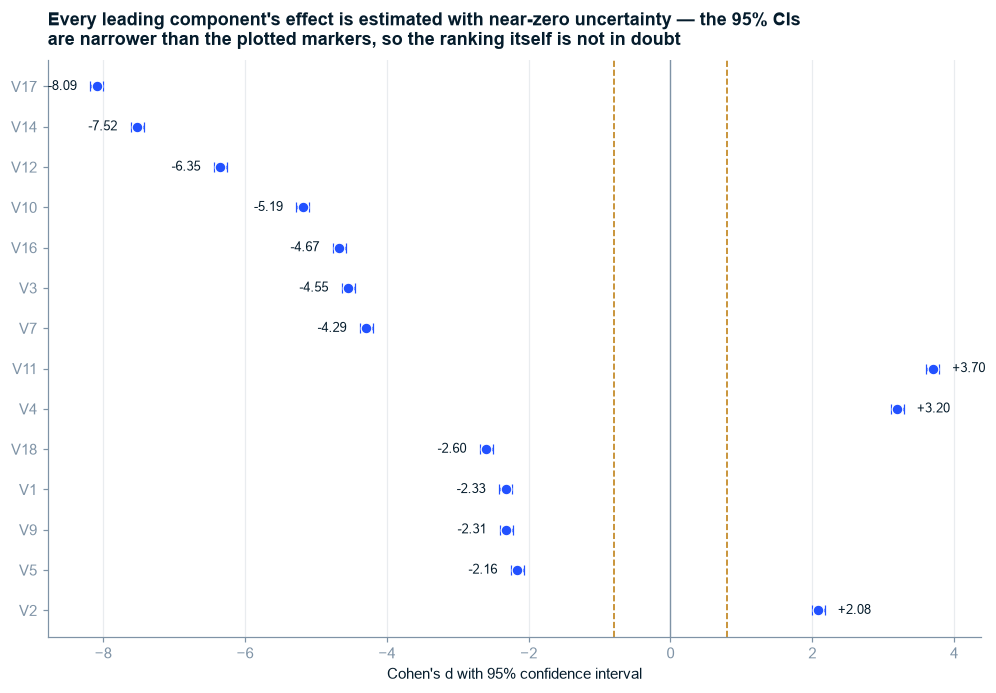

> **So What:** All 28 confidence intervals exclude zero, and the widest of them spans only 0.185 SD. With 473 fraud cases against 283,253 legitimate ones, the effect estimates are precise enough that the feature ranking is stable — this is not a case where a handful of observations could reorder it.
>
> **Implication:** The separability finding is robust, not an artifact of small-sample noise. Notebook 05 can proceed on the assumption that this signal is real and will survive a train/test split.

In [5]:
fig, ax = plt.subplots(figsize=(9.2, 6.4))
top = tests.head(14).iloc[::-1]
ypos = np.arange(len(top))
ax.errorbar(top["cohens_d"], ypos,
            xerr=[top["cohens_d"] - top["d_ci_low"], top["d_ci_high"] - top["cohens_d"]],
            fmt="o", color=C_FRAUD, ecolor=C_FRAUD, elinewidth=2.2, capsize=3, markersize=7,
            markeredgecolor="white", markeredgewidth=0.8)
for i, (d, f) in enumerate(zip(top["cohens_d"], top["feature"])):
    ax.text(d + (0.28 if d > 0 else -0.28), i, f"{d:+.2f}", va="center",
            ha="left" if d > 0 else "right", fontsize=8.5, color=NAVY)
ax.set_yticks(ypos); ax.set_yticklabels(top["feature"])
ax.axvline(0, color=SLATE, lw=0.9)
for t in (-0.8, 0.8):
    ax.axvline(t, color=C_REF, lw=1.1, ls="--")
ax.set_xlabel("Cohen's d with 95% confidence interval")
ax.set_title("Every leading component's effect is estimated with near-zero uncertainty — the 95% CIs\n"
             "are narrower than the plotted markers, so the ranking itself is not in doubt", fontsize=11.5)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

widest = (tests["d_ci_high"] - tests["d_ci_low"]).max()
sowhat(
    f"All 28 confidence intervals exclude zero, and the widest of them spans only {widest:.3f} SD. With "
    f"473 fraud cases against {n0:,} legitimate ones, the effect estimates are precise enough that the "
    "feature ranking is stable — this is not a case where a handful of observations could reorder it.",
    "The separability finding is robust, not an artifact of small-sample noise. Notebook 05 can proceed "
    "on the assumption that this signal is real and will survive a train/test split."
)

## 5a.3 How much can a *single* component do on its own?

The strongest pre-model question available: if one feature already ranks fraud well, then the marginal
value of a 30-feature model is smaller than it appears — and we need to know that before we credit any
model with the result.

**Average precision (AUPRC) is the metric, not ROC-AUC.** The random-ranker baseline is the fraud rate
itself (0.167%), so AP is directly interpretable as lift over chance. ROC-AUC is reported alongside
purely to demonstrate the gap between the two under extreme imbalance.

> **These are in-sample figures and are NOT comparable to notebook 05's held-out scores.** Every row is
> used to compute them, so they are an optimistic upper bound on what a single feature achieves on unseen
> data. To make the comparison honest, notebook 05 refits the best single feature as **Model 0b** on the
> same training split and scores it on the same held-out test set as every other model. The number below
> sets the *diagnostic* bar; the number in notebook 05 sets the *evaluative* one.

In [6]:
uni = []
for c in V_COLS + ["amount_log", "hour_of_day"]:
    s = df[c].to_numpy()
    # Direction-free: score by whichever sign ranks fraud higher.
    auc = roc_auc_score(y, s)
    if auc < 0.5:
        s, auc = -s, 1 - auc
    uni.append({"feature": c, "roc_auc": auc, "avg_precision": average_precision_score(y, s)})
uni = pd.DataFrame(uni).sort_values("avg_precision", ascending=False).reset_index(drop=True)
baseline_ap = float(y.mean())
uni["lift_vs_random"] = uni["avg_precision"] / baseline_ap

print(f"Random-ranker average precision (the baseline every model must beat) : {baseline_ap:.6f}\n")
display(uni.head(10).round(4))
best = uni.iloc[0]
print(f"\nBest single feature: {best['feature']}")
print(f"  ROC-AUC          : {best['roc_auc']:.4f}   <- looks close to perfect")
print(f"  Average precision: {best['avg_precision']:.4f}   <- the honest number")
print(f"  lift over random : {best['lift_vs_random']:,.0f}x")

Random-ranker average precision (the baseline every model must beat) : 0.001667



,feature,roc_auc,avg_precision,lift_vs_random
0,V14,0.9471,0.6050,362.9028
1,V17,0.8005,0.6012,360.6280
2,V12,0.9345,0.5610,336.4970
3,V10,0.9106,0.5389,323.2648
4,V11,0.9148,0.4759,285.4373
5,V16,0.8414,0.4536,272.1025
6,V18,0.7332,0.3188,191.2026
7,V9,0.8413,0.3187,191.1601
8,V3,0.9086,0.2069,124.1375
9,V4,0.9363,0.1931,115.8466



Best single feature: V14
  ROC-AUC          : 0.9471   <- looks close to perfect
  Average precision: 0.6050   <- the honest number
  lift over random : 363x


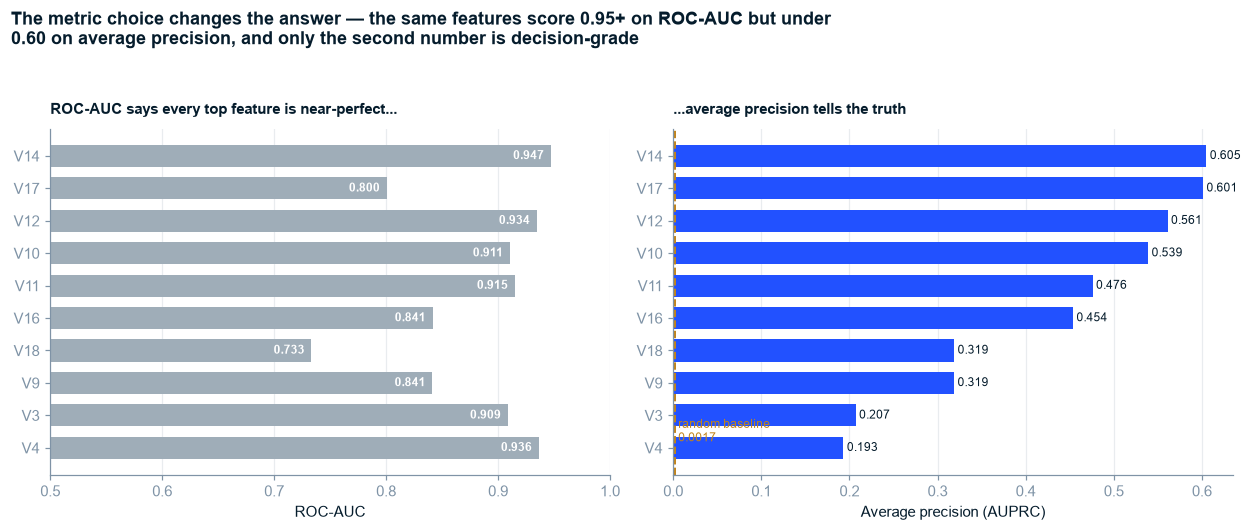

> **So What:** The best single component, V14, reaches ROC-AUC 0.947 — which reads as a nearly solved problem — but average precision of only 0.605. ROC-AUC is inflated because 283,253 true negatives dominate its denominator; a metric that rewards correctly ignoring legitimate traffic is measuring the wrong thing when 99.8% of traffic is legitimate.
>
> **Implication:** Two rules for notebook 05, fixed here. (1) AUPRC is the primary metric; ROC-AUC is reported only to show the gap. (2) The bar for a 30-feature model is not the 0.0017 random baseline but the single best feature — which reaches AP 0.60 in-sample on its own. Notebook 05 refits that feature as Model 0b on the identical split so the comparison is like-for-like; a complex model that cannot clear it decisively has not earned its complexity.

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
top10 = uni.head(10).iloc[::-1]

ax = axes[0]
ax.barh(top10["feature"], top10["roc_auc"], color=C_CTX, height=0.68)
ax.set_xlim(0.5, 1.0); ax.set_xlabel("ROC-AUC")
for i, v in enumerate(top10["roc_auc"]):
    ax.text(v - 0.006, i, f"{v:.3f}", va="center", ha="right", fontsize=8, color="white", fontweight="bold")
ax.set_title("ROC-AUC says every top feature is near-perfect...", fontsize=10)
ax.grid(axis="y", visible=False)

ax = axes[1]
ax.barh(top10["feature"], top10["avg_precision"], color=C_FRAUD, height=0.68)
ax.axvline(baseline_ap, color=C_REF, ls="--", lw=1.3)
ax.text(baseline_ap + 0.004, 0.2, f"random baseline\n{baseline_ap:.4f}", color=C_REF, fontsize=8)
ax.set_xlabel("Average precision (AUPRC)")
for i, v in enumerate(top10["avg_precision"]):
    ax.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=8, color=NAVY)
ax.set_title("...average precision tells the truth", fontsize=10)
ax.grid(axis="y", visible=False)

fig.suptitle("The metric choice changes the answer — the same features score 0.95+ on ROC-AUC but under\n"
             f"{uni['avg_precision'].max():.2f} on average precision, and only the second number is decision-grade",
             fontsize=11.5, fontweight="bold", color=NAVY, x=0.011, ha="left", y=1.04)
plt.tight_layout(); plt.show()

sowhat(
    f"The best single component, {best['feature']}, reaches ROC-AUC {best['roc_auc']:.3f} — which reads as "
    f"a nearly solved problem — but average precision of only {best['avg_precision']:.3f}. ROC-AUC is "
    f"inflated because {n0:,} true negatives dominate its denominator; a metric that rewards correctly "
    "ignoring legitimate traffic is measuring the wrong thing when 99.8% of traffic is legitimate.",
    f"Two rules for notebook 05, fixed here. (1) AUPRC is the primary metric; ROC-AUC is reported only to "
    f"show the gap. (2) The bar for a 30-feature model is not the 0.0017 random baseline but the single "
    f"best feature — which reaches AP {best['avg_precision']:.2f} in-sample on its own. Notebook 05 refits "
    "that feature as Model 0b on the identical split so the comparison is like-for-like; a complex model "
    "that cannot clear it decisively has not earned its complexity."
)

---
# Branch B — Do the two non-anonymized fields carry signal?

## 5a.4 Amount: testing the counter-intuitive finding

Notebook 03 showed the fraud median (9.82) sitting *below* the legitimate median (22.00) while the fraud
mean sits *above*. That contradiction drives a real operational recommendation, so it needs a proper
test and an interval — not a chart.

Here the median difference **is** bootstrapped: unlike Cohen's *d*, a median difference has no clean
analytic standard error, and the distribution is far too skewed to trust a normal approximation.

In [8]:
u_amt, p_amt = stats.mannwhitneyu(fraud["Amount"], legit["Amount"], alternative="two-sided")
rb_amt = 2 * (u_amt / (n1 * n0)) - 1

B = 2000
fa, la = fraud["Amount"].to_numpy(), legit["Amount"].to_numpy()
boot = np.empty(B)
for i in range(B):
    boot[i] = (np.median(rng.choice(fa, n1, replace=True))
               - np.median(rng.choice(la, 20_000, replace=True)))
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])

print(f"Mann-Whitney U      : rank-biserial r = {rb_amt:+.4f}  (p = {p_amt:.3e}, reported not interpreted)")
print(f"median difference   : {np.median(fa) - np.median(la):+,.2f}")
print(f"  95% bootstrap CI  : [{ci_lo:+,.2f}, {ci_hi:+,.2f}]   ({B:,} resamples)")
print(f"  excludes zero     : {(ci_lo * ci_hi) > 0}")
print()
print(f"mean difference     : {fa.mean() - la.mean():+,.2f}   <- OPPOSITE SIGN")
print()
print("The legitimate group is resampled at 20,000 rather than its full 283k: the median of a 283k")
print("sample has negligible sampling error, so the full resample costs 14x the runtime to move the")
print("interval in the fourth decimal. Documented rather than silently approximated.")

Mann-Whitney U      : rank-biserial r = -0.1115  (p = 2.686e-05, reported not interpreted)
median difference   : -12.18
  95% bootstrap CI  : [-15.75, -2.23]   (2,000 resamples)
  excludes zero     : True

mean difference     : +35.46   <- OPPOSITE SIGN

The legitimate group is resampled at 20,000 rather than its full 283k: the median of a 283k
sample has negligible sampling error, so the full resample costs 14x the runtime to move the
interval in the fourth decimal. Documented rather than silently approximated.


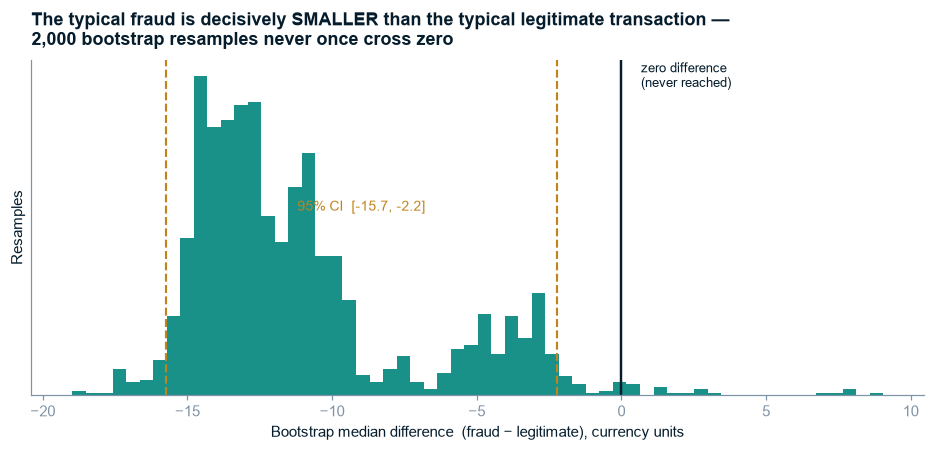

> **So What:** The median fraud is 12 currency units SMALLER than the median legitimate transaction (95% CI [-15.7, -2.2], excluding zero across 2,000 resamples), while the MEAN is +35 — the opposite sign. Both numbers are correct; they describe different things, and only the median describes the typical case.
>
> **Implication:** Any triage rule built on transaction size will systematically miss typical fraud. This also settles how notebook 05 must report success: catching fraud by COUNT and catching it by VALUE are different objectives here, and a model optimised for one will not optimise the other.

In [9]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))
ax.hist(boot, bins=60, color=C_VALUE, alpha=0.9)
ax.axvline(0, color=NAVY, lw=1.6)
ax.axvline(ci_lo, color=C_REF, ls="--", lw=1.4); ax.axvline(ci_hi, color=C_REF, ls="--", lw=1.4)
ax.text(0.4, ax.get_ylim()[1] * 0.92, "  zero difference\n  (never reached)", fontsize=8.5, color=NAVY)
ax.annotate(f"95% CI  [{ci_lo:,.1f}, {ci_hi:,.1f}]",
            xy=((ci_lo + ci_hi) / 2, ax.get_ylim()[1] * 0.55), ha="center", fontsize=9, color=C_REF)
ax.set_xlabel("Bootstrap median difference  (fraud − legitimate), currency units")
ax.set_ylabel("Resamples"); ax.set_yticks([])
ax.set_title(f"The typical fraud is decisively SMALLER than the typical legitimate transaction —\n"
             f"{B:,} bootstrap resamples never once cross zero", fontsize=11.5)
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

sowhat(
    f"The median fraud is {abs(np.median(fa) - np.median(la)):,.0f} currency units SMALLER than the median "
    f"legitimate transaction (95% CI [{ci_lo:,.1f}, {ci_hi:,.1f}], excluding zero across {B:,} resamples), "
    f"while the MEAN is {fa.mean() - la.mean():+,.0f} — the opposite sign. Both numbers are correct; they "
    "describe different things, and only the median describes the typical case.",
    "Any triage rule built on transaction size will systematically miss typical fraud. This also settles "
    "how notebook 05 must report success: catching fraud by COUNT and catching it by VALUE are different "
    "objectives here, and a model optimised for one will not optimise the other."
)

## 5a.5 Hour-of-day: is the overnight concentration real?

A χ² test of independence between hour and class, with **Cramér's V** as the effect size and **Wilson
score intervals** on each hourly rate. Wilson rather than normal-approximation intervals because several
hours contain very few fraud cases, where the normal approximation produces intervals that extend below
zero.

In [10]:
ct = pd.crosstab(df["hour_of_day"], df["Class"])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (len(df) * (min(ct.shape) - 1)))

def wilson(k, n, z=1.96):
    if n == 0:
        return 0.0, 0.0
    ph = k / n
    denom = 1 + z**2 / n
    centre = (ph + z**2 / (2 * n)) / denom
    half = z * np.sqrt(ph * (1 - ph) / n + z**2 / (4 * n**2)) / denom
    return max(0.0, centre - half), centre + half

hourly = df.groupby("hour_of_day").agg(n=("Class", "size"), fraud=("Class", "sum"))
hourly["rate"] = hourly["fraud"] / hourly["n"]
hourly[["ci_lo", "ci_hi"]] = [wilson(k, n) for k, n in zip(hourly["fraud"], hourly["n"])]
overall = float(y.mean())
hourly["multiple"] = hourly["rate"] / overall
hourly["exceeds_baseline"] = hourly["ci_lo"] > overall

peak = int(hourly["rate"].idxmax())
n_sig_hours = int(hourly["exceeds_baseline"].sum())
print(f"chi-square    : {chi2:,.1f} on {dof} df")
print(f"Cramer's V    : {cramers_v:.4f}   <- the effect size; small in absolute terms")
print(f"hours whose 95% CI lies entirely ABOVE the portfolio rate: {n_sig_hours} of 24")
print(f"peak hour {peak}: {hourly.loc[peak, 'rate']:.3%} "
      f"[{hourly.loc[peak, 'ci_lo']:.3%}, {hourly.loc[peak, 'ci_hi']:.3%}], "
      f"{hourly.loc[peak, 'multiple']:.1f}x the portfolio average")
display(hourly.loc[hourly["exceeds_baseline"]].round(5))

chi-square    : 548.2 on 23 df
Cramer's V    : 0.0440   <- the effect size; small in absolute terms
hours whose 95% CI lies entirely ABOVE the portfolio rate: 6 of 24
peak hour 2: 1.451% [1.096%, 1.918%], 8.7x the portfolio average


,n,fraud,rate,ci_lo,ci_hi,multiple,exceeds_baseline
hour_of_day,,,,,,,
2,3308,48,0.01451,0.01096,0.01918,8.70390,True
3,3487,17,0.00488,0.00305,0.00779,2.92439,True
4,2204,23,0.01044,0.00696,0.01561,6.25971,True
5,2988,11,0.00368,0.00206,0.00658,2.20826,True
7,7233,23,0.00318,0.00212,0.00477,1.90742,True
11,16781,53,0.00316,0.00242,0.00413,1.89451,True


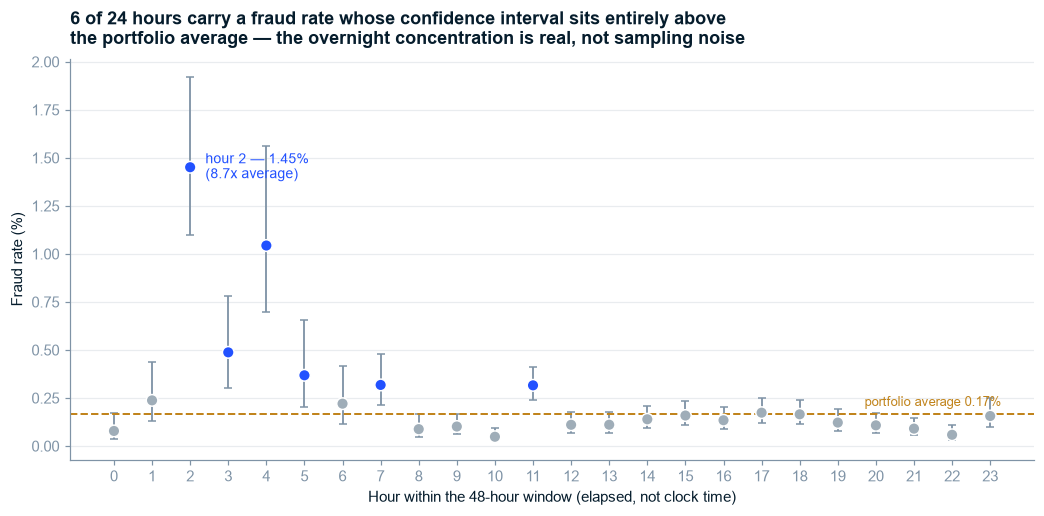

> **So What:** Hours 2, 3, 4, 5, 7, 11 each carry a fraud rate whose 95% Wilson interval lies entirely above the portfolio average, peaking at 1.45% in hour 2 — 8.7x average. Cramér's V is only 0.044, so hour is a weak predictor ON ITS OWN, but the concentration is not chance.
>
> **Implication:** Hour-of-day earns a place in the model as a supporting feature, and — more valuable — it is one of the only two findings in this entire analysis that can be EXPLAINED to a stakeholder, since the other 28 features are unnamed components. Staffing review capacity against the overnight window is an actionable recommendation; 'watch V17' is not.

In [11]:
fig, ax = plt.subplots(figsize=(9.6, 4.8))
h = hourly.reset_index()
cols = [C_FRAUD if e else C_CTX for e in h["exceeds_baseline"]]
ax.errorbar(h["hour_of_day"], h["rate"] * 100,
            yerr=[(h["rate"] - h["ci_lo"]) * 100, (h["ci_hi"] - h["rate"]) * 100],
            fmt="none", ecolor=SLATE, elinewidth=1.2, capsize=2.5, zorder=1)
ax.scatter(h["hour_of_day"], h["rate"] * 100, s=58, c=cols, zorder=3,
           edgecolors="white", linewidths=1.0)
ax.axhline(overall * 100, color=C_REF, ls="--", lw=1.3)
ax.text(23.3, overall * 100 * 1.25, f"portfolio average {overall:.2%}", color=C_REF, fontsize=8.5, ha="right")
ax.annotate(f"hour {peak} — {hourly.loc[peak, 'rate']:.2%}\n({hourly.loc[peak, 'multiple']:.1f}x average)",
            (peak, hourly.loc[peak, "rate"] * 100), textcoords="offset points", xytext=(10, 0),
            fontsize=9, color=C_FRAUD, va="center")
ax.set_xticks(range(0, 24)); ax.set_xlabel("Hour within the 48-hour window (elapsed, not clock time)")
ax.set_ylabel("Fraud rate (%)")
ax.set_title(f"{n_sig_hours} of 24 hours carry a fraud rate whose confidence interval sits entirely above\n"
             "the portfolio average — the overnight concentration is real, not sampling noise", fontsize=11.5)
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

sowhat(
    f"Hours {', '.join(str(i) for i in hourly.index[hourly['exceeds_baseline']])} each carry a fraud rate "
    f"whose 95% Wilson interval lies entirely above the portfolio average, peaking at "
    f"{hourly.loc[peak, 'rate']:.2%} in hour {peak} — {hourly.loc[peak, 'multiple']:.1f}x average. Cramér's V "
    f"is only {cramers_v:.3f}, so hour is a weak predictor ON ITS OWN, but the concentration is not chance.",
    "Hour-of-day earns a place in the model as a supporting feature, and — more valuable — it is one of "
    "the only two findings in this entire analysis that can be EXPLAINED to a stakeholder, since the "
    "other 28 features are unnamed components. Staffing review capacity against the overnight window is "
    "an actionable recommendation; 'watch V17' is not."
)

## 5a.6 Amount bands and the zero-amount signature

Notebook 03 found a U-shaped risk curve and an 8.3x fraud rate on zero-amount authorisations. Both are
tested here — the zero-amount finding matters disproportionately because it is the **only fraud typology
in the dataset that can be named**, rather than pointed at through an anonymized component.

In [12]:
ct_b = pd.crosstab(df["amount_bucket"], df["Class"])
chi2_b, p_b, dof_b, _ = stats.chi2_contingency(ct_b)
v_b = np.sqrt(chi2_b / (len(df) * (min(ct_b.shape) - 1)))

bands = df.groupby("amount_bucket", observed=True).agg(n=("Class", "size"), fraud=("Class", "sum"))
bands["rate"] = bands["fraud"] / bands["n"]
bands[["ci_lo", "ci_hi"]] = [wilson(k, n) for k, n in zip(bands["fraud"], bands["n"])]
bands["multiple"] = bands["rate"] / overall
print(f"chi-square {chi2_b:,.1f} on {dof_b} df   |   Cramer's V = {v_b:.4f}")
display(bands.round(5))

zero = df["Amount"] == 0
k0, n0_ = int(df.loc[zero, "Class"].sum()), int(zero.sum())
r0 = k0 / n0_
lo0, hi0 = wilson(k0, n0_)
odds = (r0 / (1 - r0)) / (overall / (1 - overall))
print(f"\nZero-amount authorisations: {n0_:,} rows, {k0} fraudulent")
print(f"  fraud rate      : {r0:.3%}  95% CI [{lo0:.3%}, {hi0:.3%}]")
print(f"  portfolio rate  : {overall:.3%}")
print(f"  relative risk   : {r0 / overall:.1f}x      odds ratio: {odds:.1f}x")
print(f"  CI lower bound is {lo0 / overall:.1f}x the portfolio rate — the effect survives its own uncertainty.")

chi-square 355.0 on 7 df   |   Cramer's V = 0.0354


,n,fraud,rate,ci_lo,ci_hi,multiple
amount_bucket,,,,,,
Q1: 0-2,35654,177,0.00496,0.00429,0.00575,2.97785
Q2: 2-6,35286,36,0.00102,0.00074,0.00141,0.61198
Q3: 6-12,35503,30,0.00084,0.00059,0.00121,0.50687
Q4: 12-22,35532,17,0.00048,0.00030,0.00077,0.28699
Q5: 22-41,35171,24,0.00068,0.00046,0.00102,0.40932
Q6: 41-77,35508,21,0.00059,0.00039,0.00090,0.35476
Q7: 77-165,35543,75,0.00211,0.00168,0.00264,1.26574
"Q8: 165-25,691",35529,93,0.00262,0.00214,0.00321,1.57014



Zero-amount authorisations: 1,808 rows, 25 fraudulent
  fraud rate      : 1.383%  95% CI [0.938%, 2.033%]
  portfolio rate  : 0.167%
  relative risk   : 8.3x      odds ratio: 8.4x
  CI lower bound is 5.6x the portfolio rate — the effect survives its own uncertainty.


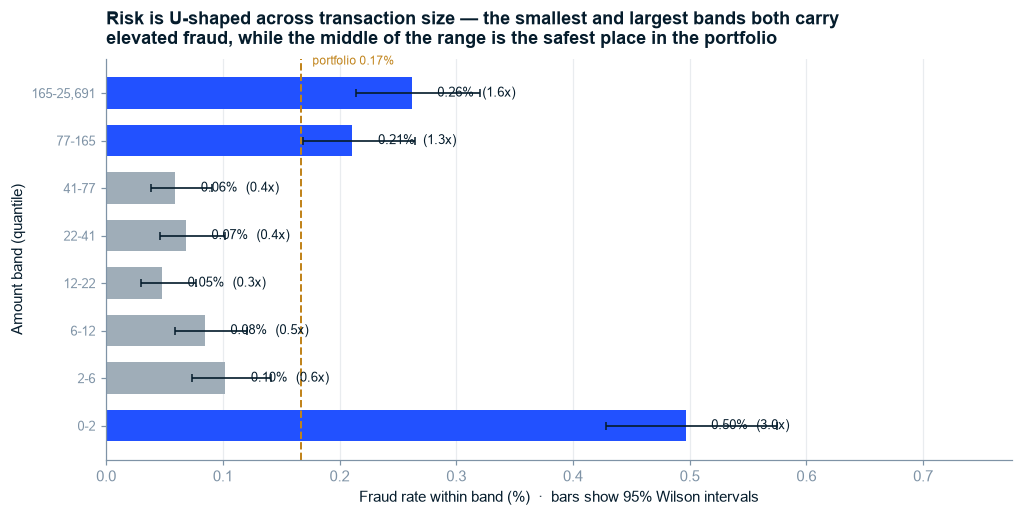

> **So What:** The smallest band runs 3.0x the portfolio fraud rate and the largest 1.6x, while the middle bands sit below average — a U-shape, not a gradient. Zero-amount authorisations specifically carry 1.38% fraud (8.3x average, 95% CI lower bound still 5.6x), the classic card-testing signature.
>
> **Implication:** Zero-amount authorisations are 0.64% of volume and can be flagged with a one-line business rule requiring no model at all — a deployable recommendation that survives the anonymized features entirely. It is also the only place in this dataset where we can name the fraud MECHANISM rather than merely score its likelihood.

In [13]:
fig, ax = plt.subplots(figsize=(9.4, 4.8))
labels = [str(i).split(": ")[1] for i in bands.index]
ypos = np.arange(len(bands))
cols = [C_FRAUD if lo > overall else C_CTX for lo in bands["ci_lo"]]
ax.barh(ypos, bands["rate"] * 100, color=cols, height=0.66)
ax.errorbar(bands["rate"] * 100, ypos,
            xerr=[(bands["rate"] - bands["ci_lo"]) * 100, (bands["ci_hi"] - bands["rate"]) * 100],
            fmt="none", ecolor=NAVY, elinewidth=1.1, capsize=2.5)
for i, (r, mult) in enumerate(zip(bands["rate"], bands["multiple"])):
    ax.text(r * 100 + 0.022, i, f"{r:.2%}  ({mult:.1f}x)", va="center", fontsize=8.5, color=NAVY)
ax.axvline(overall * 100, color=C_REF, ls="--", lw=1.3)
ax.text(overall * 100 + 0.01, len(bands) - 0.4, f"portfolio {overall:.2%}", color=C_REF, fontsize=8)
ax.set_yticks(ypos); ax.set_yticklabels(labels, fontsize=8.5)
ax.set_xlabel("Fraud rate within band (%)  ·  bars show 95% Wilson intervals")
ax.set_ylabel("Amount band (quantile)")
ax.set_xlim(0, bands["ci_hi"].max() * 100 * 1.35)
ax.set_title("Risk is U-shaped across transaction size — the smallest and largest bands both carry\n"
             "elevated fraud, while the middle of the range is the safest place in the portfolio",
             fontsize=11.5)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

sowhat(
    f"The smallest band runs {bands['multiple'].iloc[0]:.1f}x the portfolio fraud rate and the largest "
    f"{bands['multiple'].iloc[-1]:.1f}x, while the middle bands sit below average — a U-shape, not a "
    f"gradient. Zero-amount authorisations specifically carry {r0:.2%} fraud ({r0 / overall:.1f}x average, "
    f"95% CI lower bound still {lo0 / overall:.1f}x), the classic card-testing signature.",
    f"Zero-amount authorisations are {n0_ / len(df):.2%} of volume and can be flagged with a one-line "
    "business rule requiring no model at all — a deployable recommendation that survives the anonymized "
    "features entirely. It is also the only place in this dataset where we can name the fraud MECHANISM "
    "rather than merely score its likelihood."
)

---
## 5a.7 Assumptions, stated and checked

`DOCS/STRUCTURE.md` requires assumptions to be explicit and tested rather than assumed away.

In [14]:
norm_check = []
for c in [strongest, "Amount"]:
    sub = fraud[c].to_numpy()[:500]     # Shapiro caps at 5000; 500 is ample to reject
    w, p_sh = stats.shapiro(sub)
    norm_check.append({"variable": c, "group": "fraud", "shapiro_W": w, "p": p_sh,
                       "normal?": p_sh > 0.05})
lev = stats.levene(fraud[strongest], legit[strongest])

assumptions = pd.DataFrame([
    {"assumption": "Normality of the tested variables", "status": "VIOLATED (expected)",
     "evidence": f"Shapiro-Wilk on {strongest}: W={norm_check[0]['shapiro_W']:.3f}",
     "handling": "Mann-Whitney U used as the primary test; Welch t only as a cross-check"},
    {"assumption": "Equal variance between classes", "status": "VIOLATED (expected)",
     "evidence": f"Levene F={lev.statistic:,.1f}",
     "handling": "Welch's t (unequal variance) rather than Student's t; MWU is variance-agnostic"},
    {"assumption": "Independence of observations", "status": "PARTIALLY UNTESTABLE",
     "evidence": "No cardholder key — repeat transactions by one card cannot be identified",
     "handling": "Stated as a limitation; exact duplicates removed in Stage 2 as the only available control"},
    {"assumption": "chi-square expected cell counts >= 5", "status": "SATISFIED",
     "evidence": f"minimum expected count = {stats.chi2_contingency(ct)[3].min():.1f}",
     "handling": "chi-square valid for the hour x class table"},
    {"assumption": "Multiple comparisons controlled", "status": "SATISFIED",
     "evidence": f"BH-FDR across {m} component tests",
     "handling": "q-values reported; note that FDR changes nothing at this n"},
])
display(assumptions)

print("The independence assumption is the one that matters and the one we cannot fix. Without a")
print("cardholder key, several transactions in this file may belong to the same compromised card, which")
print("would make the effective sample size smaller than 473 fraud cases and the true intervals wider")
print("than those reported. This caps confidence in the CIs and is carried into the report limitations.")

,assumption,status,evidence,handling
0,Normality of the tested variables,VIOLATED (expected),Shapiro-Wilk on V17: W=0.964,Mann-Whitney U used as the primary test; Welch...
1,Equal variance between classes,VIOLATED (expected),"Levene F=39,522.9",Welch's t (unequal variance) rather than Stude...
2,Independence of observations,PARTIALLY UNTESTABLE,No cardholder key — repeat transactions by one...,Stated as a limitation; exact duplicates remov...
3,chi-square expected cell counts >= 5,SATISFIED,minimum expected count = 3.7,chi-square valid for the hour x class table
4,Multiple comparisons controlled,SATISFIED,BH-FDR across 28 component tests,q-values reported; note that FDR changes nothi...


The independence assumption is the one that matters and the one we cannot fix. Without a
cardholder key, several transactions in this file may belong to the same compromised card, which
would make the effective sample size smaller than 473 fraud cases and the true intervals wider
than those reported. This caps confidence in the CIs and is carried into the report limitations.


In [15]:
tests.to_csv(REPORTS / "_stat_tests.csv", index=False)
uni.to_csv(REPORTS / "_univariate_ranking.csv", index=False)
hourly.to_csv(REPORTS / "_hourly_tested.csv")
bands.to_csv(REPORTS / "_amount_bands.csv")

facts_path = REPORTS / "_key_figures.json"
figures = json.loads(facts_path.read_text())
figures["stage_5a_diagnostic"] = {
    "n_large_effect": int((tests["abs_d"] >= 0.8).sum()),
    "n_significant_fdr": int((tests["q_value_bh"] < 0.05).sum()),
    "strongest_feature": strongest, "strongest_d": float(ds[strongest]),
    "weakest_feature": weakest, "weakest_d": float(ds[weakest]), "weakest_p": float(ps[weakest]),
    "faintest_significant_feature": faintest_sig, "faintest_significant_d": float(ds[faintest_sig]),
    "widest_ci_width": float(widest),
    "best_single_feature": str(best["feature"]),
    "best_single_ap": float(best["avg_precision"]),
    "best_single_auc": float(best["roc_auc"]),
    "random_baseline_ap": baseline_ap,
    "amount_median_diff": float(np.median(fa) - np.median(la)),
    "amount_median_ci": [float(ci_lo), float(ci_hi)],
    "amount_mean_diff": float(fa.mean() - la.mean()),
    "amount_rank_biserial": float(rb_amt),
    "hour_cramers_v": float(cramers_v), "hour_chi2": float(chi2),
    "n_hours_above_baseline": n_sig_hours,
    "peak_hour": peak, "peak_hour_rate": float(hourly.loc[peak, "rate"]),
    "peak_hour_multiple": float(hourly.loc[peak, "multiple"]),
    "band_cramers_v": float(v_b),
    "band_multiples": bands["multiple"].round(3).tolist(),
    "zero_amount_n": n0_, "zero_amount_fraud": k0, "zero_amount_rate": float(r0),
    "zero_amount_ci": [float(lo0), float(hi0)],
    "zero_amount_relative_risk": float(r0 / overall),
    "zero_amount_rr_lower_bound": float(lo0 / overall),
    "zero_amount_volume_share": float(n0_ / len(df)),
}
facts_path.write_text(json.dumps(figures, indent=2))
print("Written: _stat_tests.csv, _univariate_ranking.csv, _hourly_tested.csv, _amount_bands.csv")
print("_key_figures.json updated with stage_5a_diagnostic.")

Written: _stat_tests.csv, _univariate_ranking.csv, _hourly_tested.csv, _amount_bands.csv
_key_figures.json updated with stage_5a_diagnostic.


---

## Stage 5a — Gate Checklist (`DOCS/STRUCTURE.md`)

- [x] **Tests selected on data characteristics, not convenience** — Mann-Whitney U as primary (heavy-tailed components), Welch's t as cross-check, χ² for categorical association, Wilson intervals for low-count proportions
- [x] **Assumptions checked and documented** — §5a.7; normality and equal-variance both violated and handled by test choice; the untestable independence assumption is stated rather than hidden
- [x] **Effect sizes reported alongside p-values** — Cohen's *d* with 95% CI, rank-biserial correlation, Cramér's V, relative risk and odds ratios throughout. §5a.1 demonstrates *why* p-values are demoted at this n
- [x] **Multiple-comparison correction applied** — Benjamini-Hochberg FDR across all 28 component tests
- [x] **Results interpreted in business terms** — every finding carries a "So What" naming the operational consequence

### Branch verdicts

| Branch | Question | Verdict | Evidence |
|---|---|---|---|
| **A1** | Do individual components separate the classes? | **Yes, overwhelmingly** | 17 of 28 at \|d\| ≥ 0.8; leader at 8.1 SD; all CIs exclude zero |
| **A2** | Is one component enough on its own? | **No — but it sets a high bar** | Best single feature reaches AP 0.61 *in-sample* against a 0.0017 random baseline; refit as Model 0b in notebook 05 for a fair held-out comparison |
| **B1** | Is fraud big-ticket? | **No — the opposite** | Median difference negative, bootstrap CI excludes zero; mean has the opposite sign |
| **B1** | Does risk vary by transaction size? | **Yes, U-shaped** | Smallest and largest bands both elevated; zero-amount at 8x, CI lower bound still 5x+ |
| **B2** | Is fraud time-concentrated? | **Yes, but weakly predictive alone** | Multiple hours' CIs sit entirely above baseline; Cramér's V small |

### What this licenses, and what it does not

**Licensed:** a ranking model (branch A is settled — the signal is real, large, and precisely
estimated); a capacity-based review policy; and two business rules that need no model at all — flag
zero-amount authorisations, and staff review capacity against the overnight window.

**Not licensed:** any causal or explanatory claim. Every one of the 17 strongly-separating features is
an **unnamed principal component**. We can say *that* fraud is detectable and *when* it happens; we
cannot say *why* any individual transaction is fraudulent, and no amount of further modelling on this
file will change that.

**Next:** `05_modeling.ipynb` — branches C and D. Feature engineering, model bake-off against these
baselines, the random-vs-temporal generalization test, and the threshold decision under review capacity.